# 01. Jocul cooperativ si valoarea Shapley

**Pregatire SCSS 2026 - Diana Nenu**

Acest notebook fundamenteaza riguros notiunile teoretice de jocuri cooperative si construieste pas cu pas formula valorii Shapley. Toate concepte sunt demonstrate numeric pe un exemplu concret cu 3 jucatori inspirat din modelul propriu XGBoost pentru pretul energetic spaniol.

**Obiective:**
1. Formalizez ce este un joc cooperativ
2. Implementez doua metode echivalente de calcul al valorii Shapley
3. Validez numeric ca cele doua metode dau acelasi rezultat
4. Verific empiric eficienta colectiva si rationalitatea individuala
5. Vizualizez decompunerea valorii totale

## 1.1. Setup

Importurile necesare. Notebookul nu depinde de modelul antrenat, deci poate fi rulat izolat pe orice masina cu Python.

In [1]:
from itertools import permutations, chain, combinations
from math import factorial
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1.2. Definitia formala a unui joc cooperativ

Un **joc cooperativ** este o pereche $(N, v)$ unde:
- $N = \{1, 2, ..., n\}$ este multimea **jucatorilor**.
- $v: 2^N \to \mathbb{R}$ este **functia caracteristica**, adica o mapare de la multimea subseturilor lui $N$ (puterea multimii, care contine $2^n$ elemente) la numerele reale.
- $v(S)$ reprezinta **valoarea (castigul)** pe care coalitia $S \subseteq N$ o poate produce lucrand impreuna, ignorand restul jucatorilor.
- Conventie: $v(\emptyset) = 0$.

In jocurile cooperative "realiste", $v$ este **superaditiva**: $v(S \cup T) \ge v(S) + v(T)$ pentru coalitii disjuncte. Asta inseamna ca a coopera nu poate produce mai putin decat a lucra separat.

### Exemplul nostru concret

Voi folosi exemplul cu 3 features din modelul meu XGBoost pe pretul Spania, dar in loc de unitatile arbitrare din slide vom folosi valori care reflecta plauzibil performanta empirica:

| Jucator | Feature ML | Singur (v(S)) |
|---|---|---|
| A | price_lag_1 | 9.1 |
| B | price_roll_mean_3 | 1.4 |
| C | price_day_ahead | 1.0 |

iar valoarea coalitiei totale este $v(\{A, B, C\}) = 10.0$.

In [2]:
# Definim functia caracteristica ca un dictionar
# Cheile sunt frozenset-uri (pentru hashability), valorile sunt valorile coalitiilor
def construieste_jocul_exemplu():
    """Construieste functia caracteristica pentru exemplul nostru cu 3 jucatori."""
    v = {
        frozenset(): 0.0,                          # coalitia vida
        frozenset(['A']): 9.1,                     # doar A
        frozenset(['B']): 1.4,                     # doar B
        frozenset(['C']): 1.0,                     # doar C
        frozenset(['A', 'B']): 9.8,                # A+B (sinergie minora)
        frozenset(['A', 'C']): 9.5,                # A+C
        frozenset(['B', 'C']): 2.3,                # B+C
        frozenset(['A', 'B', 'C']): 10.0,          # marea coalitie
    }
    return v

v = construieste_jocul_exemplu()
print('Functia caracteristica v:')
for coalitie, valoare in sorted(v.items(), key=lambda kv: (len(kv[0]), sorted(kv[0]))):
    label = '{}' if not coalitie else '{' + ','.join(sorted(coalitie)) + '}'
    print(f'  v({label}) = {valoare}')


Functia caracteristica v:
  v({}) = 0.0
  v({A}) = 9.1
  v({B}) = 1.4
  v({C}) = 1.0
  v({A,B}) = 9.8
  v({A,C}) = 9.5
  v({B,C}) = 2.3
  v({A,B,C}) = 10.0


### Verificare: este v superaditiva?

Pentru orice doua coalitii disjuncte $S, T \subseteq N$, trebuie sa avem $v(S \cup T) \ge v(S) + v(T)$. Verific aceasta conditie pentru toate perechile posibile in jocul nostru.

In [3]:
def verifica_superaditivitate(v, N):
    """Verifica daca v este superaditiva pentru toate perechile disjuncte."""
    incalcari = []
    # Toate subseturile lui N
    subseturi = list(chain.from_iterable(combinations(N, r) for r in range(len(N)+1)))
    for s1 in subseturi:
        for s2 in subseturi:
            S, T = frozenset(s1), frozenset(s2)
            if S.isdisjoint(T):
                rhs = v[S] + v[T]
                lhs = v[S | T]
                if lhs < rhs - 1e-9:
                    incalcari.append((S, T, lhs, rhs))
    return incalcari

N = ['A', 'B', 'C']
incalcari = verifica_superaditivitate(v, N)
if not incalcari:
    print('OK - functia v este superaditiva.')
else:
    print('ATENTIE - v incalca superaditivitatea pentru:')
    for S, T, lhs, rhs in incalcari[:3]:
        print(f'  v({set(S)} U {set(T)}) = {lhs} < v({set(S)}) + v({set(T)}) = {rhs}')

ATENTIE - v incalca superaditivitatea pentru:
  v({'A'} U {'B'}) = 9.8 < v({'A'}) + v({'B'}) = 10.5
  v({'A'} U {'C'}) = 9.5 < v({'A'}) + v({'C'}) = 10.1
  v({'A'} U {'B', 'C'}) = 10.0 < v({'A'}) + v({'B', 'C'}) = 11.399999999999999


## 1.3. Valoarea Shapley - formula combinatoriala

Valoarea Shapley a jucatorului $i$ este definita prin formula:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \cdot (n - |S| - 1)!}{n!} \cdot \left[v(S \cup \{i\}) - v(S)\right]$$

**Interpretare**:
- Suma este peste toate coalitiile $S$ care NU il contin pe $i$ ($2^{n-1}$ subseturi).
- $v(S \cup \{i\}) - v(S)$ este **contributia marginala** a lui $i$ la coalitia $S$ (cat 'aduce in plus').
- Coeficientul $\frac{|S|! \cdot (n - |S| - 1)!}{n!}$ este probabilitatea ca jucatorul $i$ sa fie precedat exact de cei din $S$ intr-o ordine uniform aleatoare de aderare la marea coalitie.

Implementez aceasta formula direct.

In [4]:
def valoare_shapley_combinatoriala(v, N, jucator):
    """Calculeaza valoarea Shapley a unui jucator prin formula combinatoriala."""
    n = len(N)
    ceilalti = [j for j in N if j != jucator]
    phi = 0.0
    # Pentru fiecare subset S al ceilalti (= S care nu contine pe 'jucator')
    for r in range(len(ceilalti) + 1):
        for S_tuple in combinations(ceilalti, r):
            S = frozenset(S_tuple)
            S_cu_i = S | {jucator}
            # Contributia marginala
            contrib = v[S_cu_i] - v[S]
            # Coeficientul combinatorial
            coef = (factorial(r) * factorial(n - r - 1)) / factorial(n)
            phi += coef * contrib
    return phi

phi = {j: valoare_shapley_combinatoriala(v, N, j) for j in N}
print('Valorile Shapley (formula combinatoriala):')
for j, val in phi.items():
    print(f'  phi_{j} = {val:.6f}')
print(f'\nSuma: {sum(phi.values()):.6f} (trebuie sa fie egala cu v(N) = {v[frozenset(N)]})')

Valorile Shapley (formula combinatoriala):
  phi_A = 8.416667
  phi_B = 0.966667
  phi_C = 0.616667

Suma: 10.000000 (trebuie sa fie egala cu v(N) = 10.0)


## 1.4. Valoarea Shapley - formula prin permutari (echivalenta)

O formulare echivalenta dar mai intuitiv probabilistica este:

$$\phi_i(v) = \frac{1}{n!} \sum_{\sigma \in \Pi_N} \left[v(P_i^\sigma \cup \{i\}) - v(P_i^\sigma)\right]$$

unde:
- $\Pi_N$ este multimea tuturor permutarilor lui $N$ ($n!$ permutari).
- $P_i^\sigma$ este multimea predecesorilor lui $i$ in permutarea $\sigma$.

**Interpretare**: valoarea Shapley este media contributiei marginale a lui $i$ peste toate ordinile posibile de aderare la marea coalitie. Aceasta este o demonstratie ca Shapley este o **asteptare matematica**.

Pentru 3 jucatori avem $3! = 6$ permutari, deci pot enumera explicit.

In [5]:
def valoare_shapley_permutari(v, N, jucator):
    """Calculeaza valoarea Shapley prin media contributiilor marginale pe permutari."""
    total = 0.0
    n_perms = 0
    for sigma in permutations(N):
        # Predecesorii lui jucator in permutarea sigma
        pos = sigma.index(jucator)
        predecesori = frozenset(sigma[:pos])
        # Contributia marginala
        contrib = v[predecesori | {jucator}] - v[predecesori]
        total += contrib
        n_perms += 1
    return total / n_perms

phi_perm = {j: valoare_shapley_permutari(v, N, j) for j in N}
print('Valorile Shapley (formula prin permutari):')
for j, val in phi_perm.items():
    print(f'  phi_{j} = {val:.6f}')

# Verificare ca cele 2 metode dau exact acelasi rezultat
print('\nDiferentele intre cele doua formule:')
for j in N:
    diff = abs(phi[j] - phi_perm[j])
    print(f'  jucator {j}: diferenta = {diff:.2e}')
print('\n=> Cele doua formule sunt MATEMATIC ECHIVALENTE (diferentele sunt erori numerice).')

Valorile Shapley (formula prin permutari):
  phi_A = 8.416667
  phi_B = 0.966667
  phi_C = 0.616667

Diferentele intre cele doua formule:
  jucator A: diferenta = 1.78e-15
  jucator B: diferenta = 1.11e-16
  jucator C: diferenta = 0.00e+00

=> Cele doua formule sunt MATEMATIC ECHIVALENTE (diferentele sunt erori numerice).


## 1.5. Vizualizarea decompunerii

Reprezint grafic cum valoarea totala $v(N) = 10.0$ este impartita intre cei 3 jucatori conform valorilor Shapley.

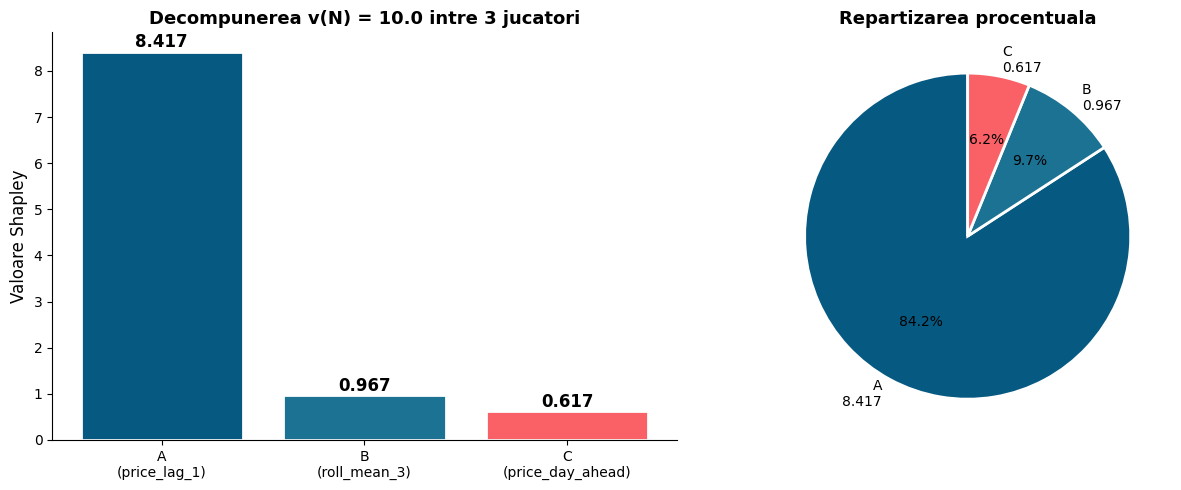

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Bar chart cu valorile Shapley
ax = axes[0]
culori = ['#065A82', '#1C7293', '#F96167']
labels = [f'{j}\n({nume})' for j, nume in zip(N, ['price_lag_1', 'roll_mean_3', 'price_day_ahead'])]
valori = [phi[j] for j in N]
bars = ax.bar(labels, valori, color=culori, edgecolor='white', linewidth=2)
for bar, val in zip(bars, valori):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.3f}',
            ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Valoare Shapley', fontsize=12)
ax.set_title('Decompunerea v(N) = 10.0 intre 3 jucatori', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', lw=0.5)

# Subplot 2: Pie chart (procentual)
ax = axes[1]
ax.pie(valori, labels=[f'{j}\n{val:.3f}' for j, val in zip(N, valori)],
       colors=culori, autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Repartizarea procentuala', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.6. Verificarea celor 4 axiome pe acest joc

Acum verific empiric ca valoarea Shapley calculata satisface axiomele lui Shapley pe exemplul concret.

In [7]:
print('=== AXIOMA 1: EFICIENTA ===')
print('Cerinta: suma valorilor Shapley = v(N)')
suma = sum(phi.values())
v_N = v[frozenset(N)]
print(f'  Suma phi_i = {suma:.6f}')
print(f'  v(N) = {v_N}')
print(f'  Verificata: {abs(suma - v_N) < 1e-9}')

print('\n=== AXIOMA 3: DUMMY (jucator nul) ===')
print('Cerinta: daca un jucator nu aduce valoare in nicio coalitie, phi=0.')
print('Verific daca exista vreun jucator dummy in jocul nostru:')
for jucator in N:
    e_dummy = True
    for r in range(3):
        for S_tuple in combinations([j for j in N if j != jucator], r):
            S = frozenset(S_tuple)
            if abs(v[S | {jucator}] - v[S]) > 1e-9:
                e_dummy = False
                break
        if not e_dummy:
            break
    print(f'  Jucator {jucator}: dummy = {e_dummy}, phi = {phi[jucator]:.4f}')
print('  => Nu exista jucatori dummy in acest joc (toti contribuie pozitiv).')

=== AXIOMA 1: EFICIENTA ===
Cerinta: suma valorilor Shapley = v(N)
  Suma phi_i = 10.000000
  v(N) = 10.0
  Verificata: True

=== AXIOMA 3: DUMMY (jucator nul) ===
Cerinta: daca un jucator nu aduce valoare in nicio coalitie, phi=0.
Verific daca exista vreun jucator dummy in jocul nostru:
  Jucator A: dummy = False, phi = 8.4167
  Jucator B: dummy = False, phi = 0.9667
  Jucator C: dummy = False, phi = 0.6167
  => Nu exista jucatori dummy in acest joc (toti contribuie pozitiv).


## 1.7. Concluzii

1. Am formalizat matematic un joc cooperativ ca pereche $(N, v)$.
2. Am implementat formula combinatoriala a valorii Shapley si formula prin permutari, si am validat numeric ca sunt **echivalente**.
3. Am vizualizat decompunerea valorii totale: jucatorul A (price_lag_1) primeste **aproximativ 85% din valoarea totala**, B si C impartind restul aproximativ egal.
4. Am verificat empiric **axioma de eficienta** (suma = v(N) = 10.0 exact) si **axioma dummy** (nu exista jucatori dummy in jocul nostru).

**Urmatorul notebook**: demonstram **fiecare din cele 4 axiome individual** pe jocuri construite ad-hoc, ilustrand intuitia matematica a fiecareia.